In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import math 
import sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
#make a train-test split 

## Importing Data

In [2]:
filename1 = 'Combined_Data_Week0.csv'
filename2 = 'Combined_Data_Week2.csv'
filename3 = 'Combined_Data_Week4.csv'
week0_data = pd.read_csv(filename1).drop('Unnamed: 0',axis=1)
week2_data = pd.read_csv(filename2).drop('Unnamed: 0',axis=1)
week4_data = pd.read_csv(filename3).drop('Unnamed: 0',axis=1)
week0_data

,Channel Name,Subscriber Count,Total Videos,Total Views,View Count,Like Count,Comment Count,Video Posted,Video Link,time_since_posting,Sub/NumberVids,Total Views/Total Videos,View/Sub
0,The Infographics Show,14800000,5354,6251451295,14149,936,225,2025-02-11 00:11:00,https://www.youtube.com/watch?v=w2SYMSemBI0&ab...,0,2764.288383,1.167623e+06,0.000956
1,The Infographics Show,14800000,5354,6251451295,267615,9021,1621,2025-02-09 15:11:00,https://www.youtube.com/watch?v=beWI6TOjXG4&ab...,1,2764.288383,1.167623e+06,0.018082
2,The Infographics Show,14800000,5354,6251451295,25730,338,26,2025-02-09 03:11:00,https://www.youtube.com/watch?v=XVS3vFs7sBU&ab...,2,2764.288383,1.167623e+06,0.001739
3,The Infographics Show,14800000,5354,6251451295,67402,1721,193,2025-02-08 15:11:00,https://www.youtube.com/watch?v=p8YmQPzknNg&ab...,2,2764.288383,1.167623e+06,0.004554
4,The Infographics Show,14800000,5354,6251451295,90882,3079,442,2025-02-08 00:37:00,https://www.youtube.com/watch?v=F9EWqjuWlwQ&ab...,3,2764.288383,1.167623e+06,0.006141
...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,Physics Explained,238000,26,11500176,213650,8049,465,2025-01-20 21:00:06,https://www.youtube.com/watch?v=vjDvBP5IU-4,21,9153.846154,4.423145e+05,0.897689
266,Physics Explained,238000,26,11500176,87393,3349,259,2025-01-27 20:00:06,https://www.youtube.com/watch?v=zvyxArI67vw,14,9153.846154,4.423145e+05,0.367197
267,Physics Explained,238000,26,11500176,19475,1362,105,2025-01-12 17:59:29,https://www.youtube.com/watch?v=hMkUdTQ2amw,29,9153.846154,4.423145e+05,0.081828
268,Periodic Videos,1620000,729,290600849,46377,3688,262,2025-01-21 13:38:06,https://www.youtube.com/watch?v=xNbDe0K-p8w,20,2222.222222,3.986294e+05,0.028628


In [3]:
date1 = pd.to_datetime('2025-02-11 00:00:00').tz_localize(None)
date2 = pd.to_datetime('2025-02-25 00:00:00').tz_localize(None)
date3 = pd.to_datetime('2025-03-13 00:00:00').tz_localize(None)

## Doing full MLR 

In [105]:
# X = week0_data[['Subscriber Count', 'Total Videos', 'Total Views', 'Like Count', 'Comment Count', 'time_since_posting', 'Sub/NumberVids']]
# X = week0_data[['Subscriber Count', 'Total Videos', 'Total Views', 'time_since_posting', 'Sub/NumberVids', 'Total Views/Total Videos', 'View/Sub']] 
X = week0_data[['Subscriber Count', 'Total Videos', 'Total Views', 'time_since_posting', 'Sub/NumberVids', 'Total Views/Total Videos', 'View/Sub']] 
# X = week0_data[['Subscriber Count', 'Total Videos', 'Total Views', 'time_since_posting', 'Sub/NumberVids']]
y = week4_data['View Count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_sm = sm.add_constant(X_train)  # Add intercept
model = sm.OLS(y_train, X_train_sm).fit()

X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

# Evaluate performance
print("Test:")
print("R-squared:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

print(model.summary())

Test:
R-squared: 0.7101592124984574
MSE: 597524653256.6333
MAE: 366566.41844464204
                            OLS Regression Results                            
Dep. Variable:             View Count   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     46.94
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           1.61e-39
Time:                        00:10:57   Log-Likelihood:                -3217.3
No. Observations:                 216   AIC:                             6451.
Df Residuals:                     208   BIC:                             6478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

## Sub/NumberVids (chosen engineered feature) 

In [14]:
X = week0_data ['Sub/NumberVids']
y = week4_data['View Count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train_sm = sm.add_constant(X_train)  # Add intercept
model = sm.OLS(y_train, X_train_sm).fit()
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)
# Evaluate performance
print("Test:")
print("R-squared:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

print(model.summary())

Test:
R-squared: 0.3758742748195725
MSE: 491935411565.20593
MAE: 383062.7336318321
                            OLS Regression Results                            
Dep. Variable:             View Count   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     177.4
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           6.99e-30
Time:                        01:44:01   Log-Likelihood:                -3277.7
No. Observations:                 216   AIC:                             6559.
Df Residuals:                     214   BIC:                             6566.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

Line of best fit: y = 118.41X + -149388.62


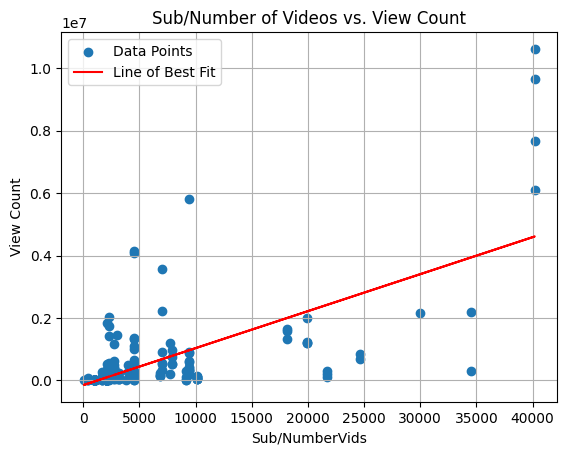

In [9]:
X = week0_data['Sub/NumberVids']
y = week4_data['View Count']
m, b = np.polyfit(X,y,1)

print(f"Line of best fit: y = {m:.2f}X + {b:.2f}")

# Optional: plot the data and the line
plt.scatter(X, y, label='Data Points')
plt.plot(X, m*X + b, color='red', label='Line of Best Fit')
plt.xlabel('Sub/NumberVids')
plt.ylabel('View Count')
plt.legend()
plt.title('Sub/Number of Videos vs. View Count')
plt.grid(True)
plt.show()

# Including Views

In [ ]:
# Select all numeric columns except the target variable
drop_columns = ['Post 2 Weeks View Count']  # Target variable
X = data.select_dtypes(include=[np.number]).drop(columns=drop_columns)
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Model evaluation
coefficients = model.coef_
intercept = model.intercept_
r_squared_train = model.score(X_train, y_train)
r_squared_test = model.score(X_test, y_test)
y_pred = model.predict(X_test)

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# OLS Regression Analysis
X_with_const = sm.add_constant(X)  # Adding a constant term for statsmodels regression
ols_model = sm.OLS(y, X_with_const).fit()
like_count_p_value = ols_model.pvalues.get('View Count', None)
print(like_count_p_value)
print(ols_model.summary())

# Plot results
plt.scatter(y_test, y_pred, label="Actual vs Predicted")
plt.xlabel('Actual Views after 2 weeks')
plt.ylabel('Predicted Views after 2 weeks')
plt.title('Multiple Linear Regression Performance')
plt.legend()
plt.show()


In [ ]:
print(X.describe())

## Single Variable OLS

In [ ]:
# Prepare data
a = np.array(data['View Count']).reshape(-1,1)
b = np.array(data['time_since_posting']).reshape(-1,1)
c = np.array(data['Post 2 Weeks View Count'])

x = data[['View Count']]
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=69)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Model evaluation
slope = model.coef_[0]
intercept = model.intercept_
r_squared_train = model.score(x_train, y_train)
r_squared_test = model.score(x_test, y_test)
y_pred = model.predict(x_test)

print(f"Slope: {slope}, Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# Plot results
plt.scatter(x,y, label="Actual Data")
plt.plot(x_test, y_pred, color='red', label="Regression Line")
plt.xlabel('Original Video Views')
plt.ylabel('Views after 2 weeks')
plt.title('Full Data Set Performance')
plt.legend()
plt.show()


## Not Including View Count

In [ ]:
# Select all numeric columns except the target variable
drop_columns = ['Post 2 Weeks View Count', 'View Count']  # Target variable
X = data.select_dtypes(include=[np.number]).drop(columns=drop_columns)
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Model evaluation
coefficients = model.coef_
intercept = model.intercept_
r_squared_train = model.score(X_train, y_train)
r_squared_test = model.score(X_test, y_test)
y_pred = model.predict(X_test)

print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# OLS Regression Analysis
X_with_const = sm.add_constant(X)  # Adding a constant term for statsmodels regression
ols_model = sm.OLS(y, X_with_const).fit()
like_count_p_value = ols_model.pvalues.get('View Count', None)
print(like_count_p_value)
print(ols_model.summary())

# Plot results
plt.scatter(y_test, y_pred, label="Actual vs Predicted")
plt.xlabel('Actual Views after 2 weeks')
plt.ylabel('Predicted Views after 2 weeks')
plt.title('Multiple Linear Regression Performance (No View Count)')
plt.legend()
plt.show()
